In [10]:
import matplotlib
import os.path

from utils.maths import *
from utils.general_functions import load_dict
from matplotlib import pyplot as plt
import logging
from meta import paths

# configure logging to show femmt terminal output
logging.basicConfig(format='%(levelname)s:%(message)s', level=logging.INFO)

# -------------------------
# Matplotlib settings
# -------------------------
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.sans-serif": ["Bitstream Vera Sans", "DejaVu Sans", "Helvetica", "Arial", "sans-serif"],
    "font.size": 10.0,
    "text.latex.preamble": r"\usepackage{upgreek}\usepackage{siunitx}",
    "mathtext.fontset": "custom",
    "mathtext.rm": "Bitstream Vera Serif",
    "mathtext.it": "Bitstream Vera Serif:italic",
    "mathtext.bf": "Bitstream Vera Serif:bold"
})

# -------------------------
# Problem definition
# -------------------------
result_folder = "performance_factor"


# -------------------------
# Plot setup
# -------------------------
cm = 1 / 2.54
comsol_color = '0.8'
colors = ["tab:pink", "tab:purple", "tab:blue", "tab:cyan", "tab:green", "tab:olive", "tab:red", "tab:orange"]

In [11]:
# Load results
results = load_dict("PF_comparison.json")

f_ = np.array(results["frequencies"])
pv_limit = results["pv_limit"]
R_ = results["radii"]
PF_static = np.array(results["PF_static"])
b_mean_static = np.array(results["b_mean_static"])
PF_dim = np.array(results["PF_dim"])
b_mean_dim = np.array(results["b_mean_dim"])


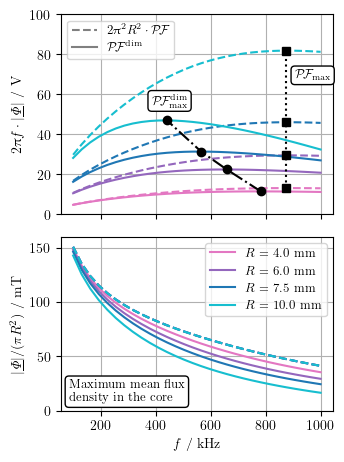

In [12]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(9 * cm, 12 * cm), sharex=True,
                       gridspec_kw={'height_ratios': [1.15, 1]})
for i, R in enumerate(R_):
    ax[0].plot(f_ / 1000, PF_static[i], "--", color=colors[i])
    ax[0].plot(f_ / 1000, PF_dim[i], color=colors[i])

    ax[1].plot(f_ / 1000, b_mean_static[i]*1000, "--", color=colors[i])
    ax[1].plot(f_ / 1000, b_mean_dim[i]*1000, label=f"$R$ = {R * 1000} mm", color=colors[i])

# Legend
ax[0].plot([], [], "--", color="gray", label=r"$2\uppi^2 R^2 \cdot \mathcal{P}\!\mathcal{F}$")
ax[0].plot([], [], color="gray", label=r"$\mathcal{P}\!\mathcal{F}^\mathrm{dim}$")
ax[0].legend(ncols=1, fontsize=9)
ax[1].legend(ncols=1, fontsize=9)


# -------------------------
# Connect maxima in upper plot and label as f_opt and f_opt^static
# -------------------------

# For PF_dim
f_opt_dim = []
PF_opt_dim = []

for i, PF in enumerate(PF_dim):
    idx_max = np.argmax(PF)
    f_opt_dim.append(f_[idx_max] / 1000)  # Hz to kHz
    PF_opt_dim.append(PF[idx_max])

# For PF_static
f_opt_static = []
PF_opt_static = []

for i, PF in enumerate(PF_static):
    idx_max = np.argmax(PF)
    f_opt_static.append(f_[idx_max] / 1000)  # Hz to kHz
    PF_opt_static.append(PF[idx_max])

# Plot connecting lines
ax[0].plot(f_opt_dim, PF_opt_dim, color="k", linestyle="-.", marker="o")
ax[0].plot(f_opt_static, PF_opt_static, color="k", linestyle=":", marker="s")

# Annotate only the first point of each
ax[0].annotate(r"$\mathcal{P}\!\mathcal{F}_{\mathrm{max}}^\mathrm{dim}$", xy=(f_opt_dim[-1], PF_opt_dim[-1]), xytext=(-11, 11),
               textcoords="offset points", fontsize=9, color="k",
               bbox=dict(facecolor='white', edgecolor='k', boxstyle='round,pad=0.3'))


ax[0].annotate(r"$\mathcal{P}\!\mathcal{F}_{\mathrm{max}}$", xy=(f_opt_static[-1], PF_opt_static[-1]), xytext=(6, -20),
               textcoords="offset points", fontsize=9, color="k",
               bbox=dict(facecolor='white', edgecolor='k', boxstyle='round,pad=0.3'))


# ax[0].text(0.5, 1.05, "Comparison of the performance factors",
#            transform=ax[0].transAxes,
#            fontsize=9, ha='left', va='bottom')

ax[1].text(0.03, 0.04, "Maximum mean flux\ndensity in the core",
           transform=ax[1].transAxes,
           fontsize=9, ha='left', va='bottom',
           bbox=dict(facecolor='white', edgecolor='k', boxstyle='round,pad=0.3'))

ax[0].set_ylim((0, 100))
ax[1].set_ylim((0, 160))

ax[0].set_ylabel(r"$2 \uppi  f \cdot |\underline{\mathit{\Phi}}|$ / V")
ax[1].set_ylabel(r"$|\underline{\mathit{\Phi}}| / (\pi R^2)$ / mT")
ax[1].set_xlabel(r"$f$ / kHz")
# ax.set_title(f"Performance Factors at {int(pv_limit/1000)} kW/m³")
ax[0].grid()
ax[1].grid()
plt.tight_layout()
plt.savefig(os.path.join("PF_comparison.pdf"))
plt.savefig(os.path.join(paths.grafics, "PF_comparison.pdf"))
plt.show()
